In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [85]:
all_od = 15448914.32101903

In [86]:
#results_path = '../experiment/output/exec2_2023_spot/results.csv'
results_path = 'output/resuts_comp_opt.csv'
results = pd.read_csv(results_path)

In [87]:
results

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
2,-0.2,0.1,1.291926e+07,1.014634
3,0.2,0.2,1.288313e+07,1.011796
4,-0.2,0.0,1.291284e+07,1.014130
5,-0.1,0.1,1.280228e+07,1.005447
6,-0.2,0.2,1.293901e+07,1.016185
7,0.1,0.1,1.279057e+07,1.004527
8,0.0,0.1,1.275374e+07,1.001635
9,0.1,0.0,1.279939e+07,1.005220


In [88]:
opt_cost = (results[results['relative_cost'] == 1]).iloc[0].tolist()[2]
relative_od_cost = all_od / opt_cost
relative_od_cost

1.2133043928381702

### Final Results

#### Only Bias

In [89]:
results_bias = results[results['sd_level'] == 0]
results_bias = results_bias.sort_values(by=['bias_level'])
results_bias

,bias_level,sd_level,cost,relative_cost
4,-0.2,0.0,1.291284e+07,1.014130
12,-0.1,0.0,1.279830e+07,1.005134
1,0.0,0.0,1.275322e+07,1.001594
0,0.0,0.0,1.273293e+07,1.000000
9,0.1,0.0,1.279939e+07,1.005220
15,0.2,0.0,1.291625e+07,1.014398


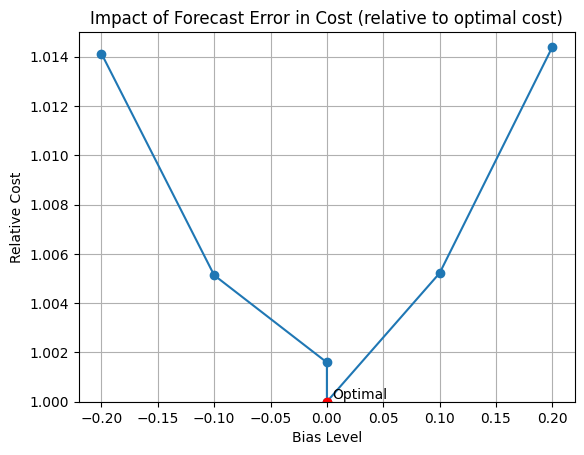

In [90]:
plt.plot(results_bias['bias_level'], results_bias['relative_cost'], marker='o', linestyle='-')

plt.plot(0, 1, 'ro')
plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

#plt.axhline(y=1.21, color='red', linestyle='--', linewidth=1)
#plt.text(0, 1.01, '100% on-demand', color='black', va='bottom', ha='center')

plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to optimal cost)')
plt.grid(True)

plt.ylim(1, 1.015)

plt.show()

#### Only SD

In [91]:
results_sd = results[results['bias_level'] == 0]
results_sd = results_sd.sort_values(by=['sd_level'])
results_sd

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
8,0.0,0.1,1.275374e+07,1.001635
13,0.0,0.2,1.275853e+07,1.002011


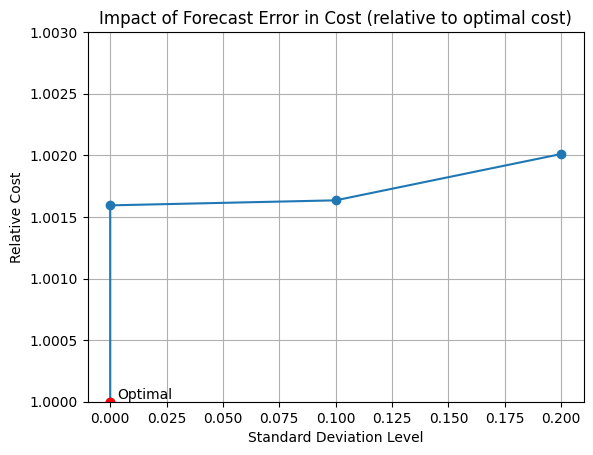

In [92]:
plt.plot(results_sd['sd_level'], results_sd['relative_cost'], marker='o', linestyle='-')

plt.plot(0, 1, 'ro')
plt.text(0.003, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.xlabel('Standard Deviation Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to optimal cost)')
plt.grid(True)
plt.ylim(1, 1.003)

plt.show()

#### Both

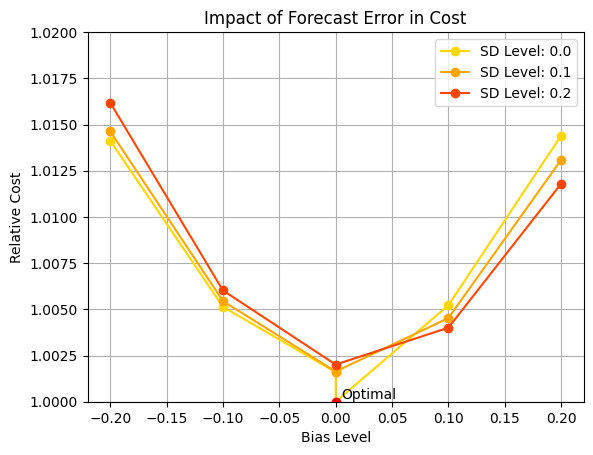

In [93]:
sd_levels = sorted(list(set(results['sd_level'])))
colors = ['gold', 'orange', 'orangered']

for i in range(len(sd_levels)):
    sd_level = sd_levels[i]
    results_sd_level = results[results['sd_level'] == sd_level]
    results_sd_level = results_sd_level.sort_values(by=['bias_level'])
    plt.plot(results_sd_level['bias_level'], results_sd_level['relative_cost'], marker='o', linestyle='-', label=f'SD Level: {sd_level}', color=colors[i])

plt.plot(0, 1, 'ro')
plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.ylim(1, 1.02)
plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost')
plt.legend()
plt.grid(True)

plt.show()

### Further analysis

#### Savings Plans Purchased

In [94]:
allocations_path = 'output/allocations'
df_sp_purchases = pd.DataFrame()


for scenario in os.listdir(allocations_path):
    scenario_path = os.path.join(allocations_path, scenario)
    scenario_name = os.path.splitext(os.path.basename(scenario_path))[0].replace("alloc_cost_", "").replace("bias", "b").replace("sd", "s")
    allocations = pd.read_csv(scenario_path)
    df_sp_purchases[scenario_name] = allocations['RNo']

In [95]:
baseline_col = "b_0.0_s_0.0"
relative_df = df_sp_purchases.div(df_sp_purchases[baseline_col], axis=0) * 100
print(relative_df.head())

   b_-0.1_s_0.0  b_0.2_s_0.0  b_-0.2_s_0.2  b_0.2_s_0.1  b_0.0_s_0.0  \
0     90.111102   119.480415     75.759906   119.140064        100.0   
1     90.110315   119.466637     78.102976   119.530839        100.0   
2     90.110315   119.466637     78.143351   119.584636        100.0   
3     90.110315   119.466637     78.309393   119.585652        100.0   
4     90.127161   119.466637     78.309393   119.585652        100.0   

   b_-0.2_s_0.0  b_0.1_s_0.1  b_-0.1_s_0.2  b_-0.2_s_0.1  b_0.1_s_0.2  \
0     80.525699   108.288281     86.461102     79.907487   108.534193   
1     80.539294   109.551361     88.112065     80.136411   108.862367   
2     80.539294   109.554981     89.254026     80.259668   109.098713   
3     80.539294   109.554981     89.254026     80.386224   109.098713   
4     80.539294   109.554981     89.375571     80.386224   109.098713   

   b_0.0_s_0.1  b_0.0_s_0.2  b_0.2_s_0.2  b_-0.1_s_0.1  b_0.1_s_0.0  
0    98.321616    96.836842   116.849017     89.106217   1

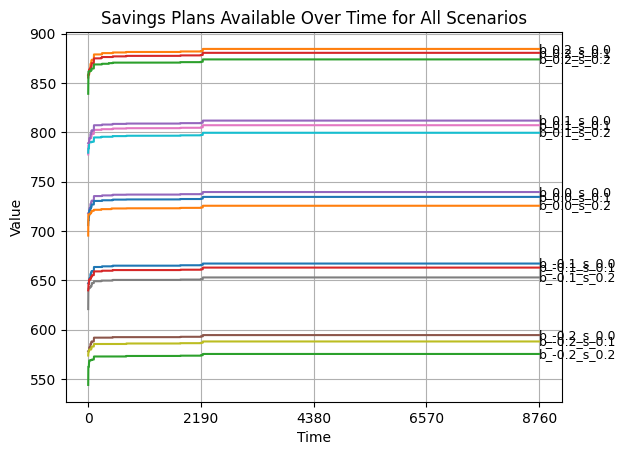

In [96]:
for col in df_sp_purchases.columns:
    line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])  # use index on x-axis

    # annotate at the last point of the line
    plt.text(
        df_sp_purchases.index[-1],       # x = last index
        df_sp_purchases[col].iloc[-1],   # y = last value
        col,                # column name as label
        color="black",      # <- always black
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for All Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()



##### Standard Deviation

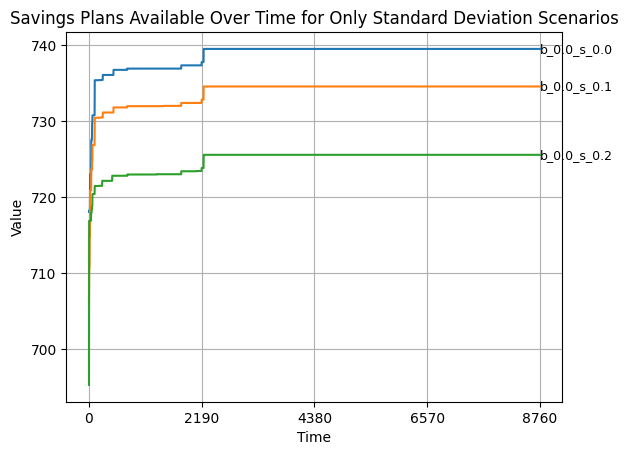

In [97]:
for col in df_sp_purchases.columns:
    bias = float(col.split('_')[1])
    if bias == 0:
        line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])

        plt.text(
            df_sp_purchases.index[-1],
            df_sp_purchases[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for Only Standard Deviation Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()

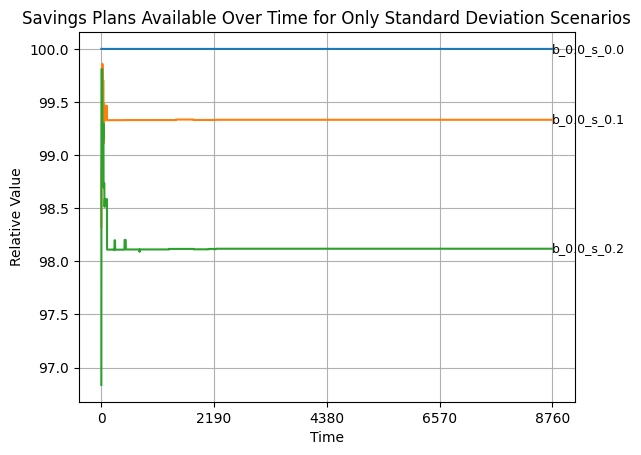

In [98]:
for col in relative_df.columns:
    bias = float(col.split('_')[1])
    if bias == 0:
        line, = plt.plot(relative_df.index, relative_df[col])

        plt.text(
            relative_df.index[-1],
            relative_df[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Only Standard Deviation Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df.index) + 1, 2190))

plt.show()

In [99]:
baseline_col = "b_0.1_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_0.1_s_0.0', 'b_0.1_s_0.1', 'b_0.1_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_0.1_s_0.0  b_0.1_s_0.1  b_0.1_s_0.2
0        100.0    98.543345    98.767128
1        100.0    99.688964    99.061997
2        100.0    99.692258    99.277066
3        100.0    99.692258    99.277066
4        100.0    99.692258    99.277066


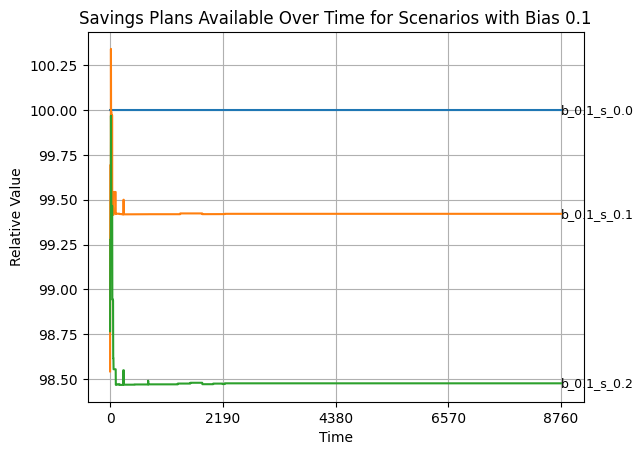

In [100]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias 0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [101]:
baseline_col = "b_0.2_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_0.2_s_0.0', 'b_0.2_s_0.1', 'b_0.2_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_0.2_s_0.0  b_0.2_s_0.1  b_0.2_s_0.2
0        100.0    99.715141    97.797632
1        100.0   100.053740    98.469354
2        100.0   100.098771    99.429055
3        100.0   100.099622    99.637009
4        100.0   100.099622   100.384379


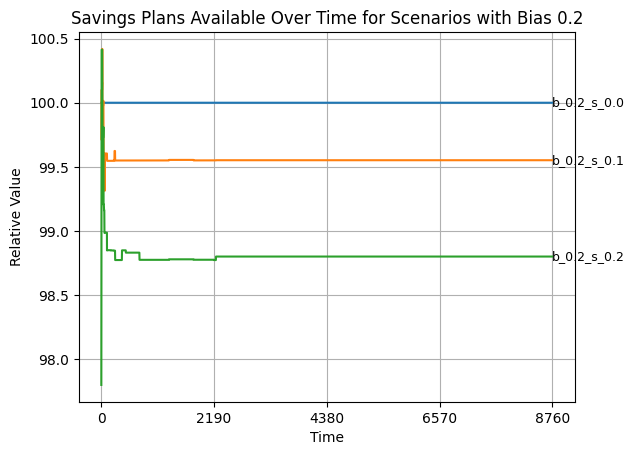

In [102]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias 0.2")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [103]:
baseline_col = "b_-0.1_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_-0.1_s_0.0', 'b_-0.1_s_0.1', 'b_-0.1_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_-0.1_s_0.0  b_-0.1_s_0.1  b_-0.1_s_0.2
0         100.0     98.884837     95.949444
1         100.0     98.955595     97.782441
2         100.0     98.974136     99.049733
3         100.0     98.974136     99.049733
4         100.0     99.695923     99.166078


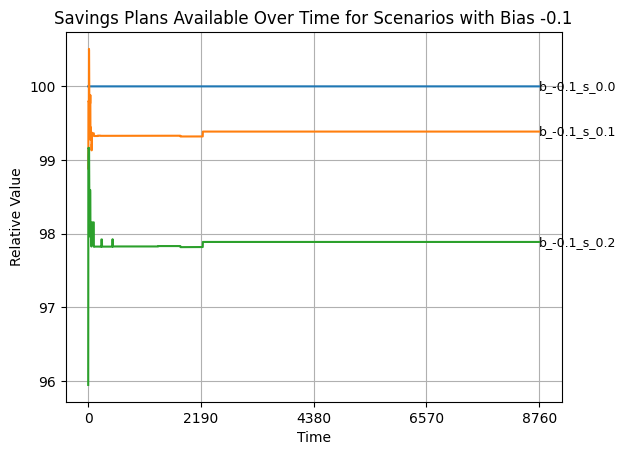

In [104]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias -0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [105]:
baseline_col = "b_-0.2_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_-0.2_s_0.0', 'b_-0.2_s_0.1', 'b_-0.2_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_-0.2_s_0.0  b_-0.2_s_0.1  b_-0.2_s_0.2
0         100.0     99.232280     94.081649
1         100.0     99.499768     96.974994
2         100.0     99.652808     97.025126
3         100.0     99.809944     97.231288
4         100.0     99.809944     97.231288


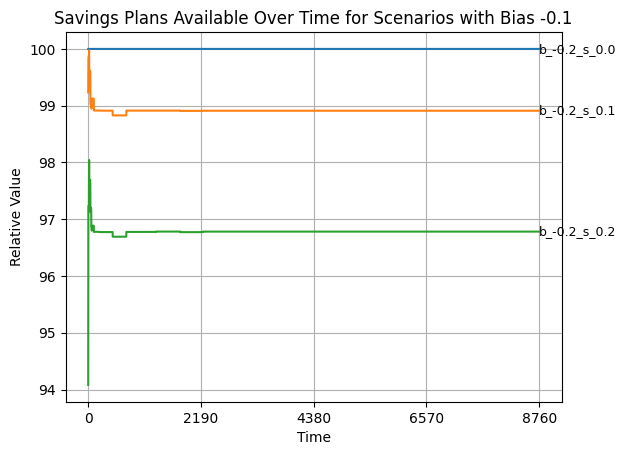

In [106]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias -0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

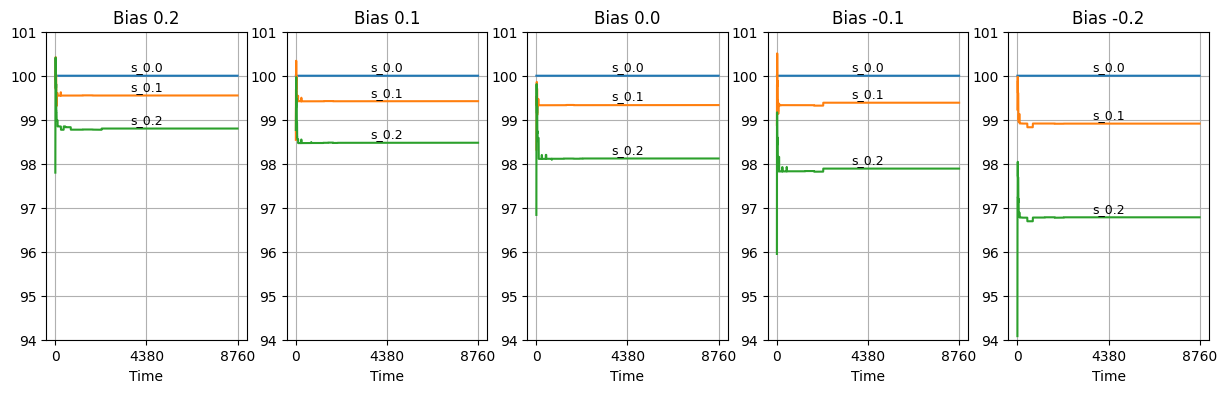

In [107]:
fig, axs = plt.subplots(1, 5, figsize=(15, 4))  # 1 row, 5 columns

bias_levels = ['0.2', '0.1','0.0', '-0.1', '-0.2']
for i, bias_level in enumerate(bias_levels):
    baseline_col = f"b_{bias_level}_s_0.0"
    df_sp_purchases_tmp = df_sp_purchases[[f'b_{bias_level}_s_0.0', f'b_{bias_level}_s_0.1', f'b_{bias_level}_s_0.2']]
    relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100

    for col in relative_df_tmp.columns:
        line, = axs[i].plot(relative_df_tmp.index, relative_df_tmp[col])

        relative = (relative_df_tmp[col] / relative_df_tmp[baseline_col]) * 100
        mid_idx = len(relative_df_tmp.index) // 2
        x_mid = relative_df_tmp.index[mid_idx]
        y_mid = relative.iloc[mid_idx]

        axs[i].annotate(
            f's_{col.split('_')[3]}',
            xy=(x_mid, y_mid + 0.05),
            color="black",
            fontsize=9,
            va="bottom", ha="center"
        )

    axs[i].set_xlabel("Time")
    axs[i].set_title(f"Bias {bias_level}")
    axs[i].grid(True)

    axs[i].set_ylim(94, 101)

    axs[i].set_xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190*2))

Aumentar a variabilidade da demanda aumenta o custo por diminuir a quantidade de compras de savings plans, o que aumenta a quantidade de instâncias compradas em on-demand (TODO: gráfico). Porém, comparando os cenários com diferentes níveis de viés, o nível de savings plans relativo comprado nos cenários com maior variabilidade varia, há casos em que ele é 97% do cenário base e casos em que é 99%. Quanto maior o viés, a compra de savings plans é mais próxima do cenário base com a mudança na variabilidade.

No início do período, os cenários com maior variabilidade reservam mais savings plans, e, ao longo do tempo, passam a ficar com menos savings plans em comparação com o cenário base (sd = 0.0). O gráfico com os valores absolutos mostra que o nível de savings plans cresce rapidamente no incío do período, para todos os cenários. Isso significa que, para cenários com maior variabilidade, esse nível cresce ainda mais rápido, mas, depois, se estabiliza em um nível menor que os cenários base. Esse crescimento mais rápido pode ser interessante de ser analisado, apesar de que a diferença é bem pequena.

##### Bias

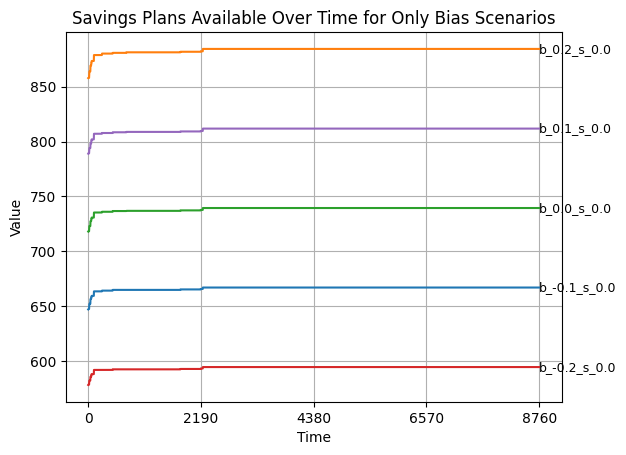

In [108]:
for col in df_sp_purchases.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])

        plt.text(
            df_sp_purchases.index[-1],
            df_sp_purchases[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for Only Bias Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()

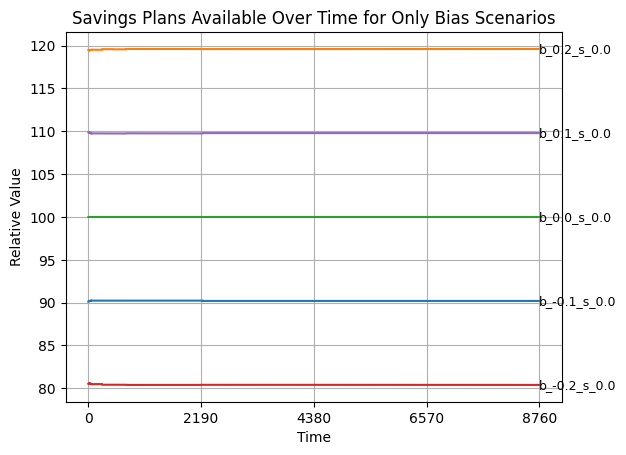

In [109]:
for col in relative_df.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(relative_df.index, relative_df[col])

        plt.text(
            relative_df.index[-1],
            relative_df[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Only Bias Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df.index) + 1, 2190))

plt.show()